In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats

In [36]:
np.random.seed(42)

In [38]:
data = {
    'product_id': range(1,21),
    'product_name' : [f'Product {i}' for i in range(1,21)],
    'category' : np.random.choice(['Electronics','Clothing','Home','Sports'],20 ) ,
    'units_sold' : np.random.poisson(lam=20,size=20),
    'sale_date' : pd.date_range(start='2023-01-01',periods=20, freq='D')
}


In [40]:
data

{'product_id': range(1, 21),
 'product_name': ['Product 1',
  'Product 2',
  'Product 3',
  'Product 4',
  'Product 5',
  'Product 6',
  'Product 7',
  'Product 8',
  'Product 9',
  'Product 10',
  'Product 11',
  'Product 12',
  'Product 13',
  'Product 14',
  'Product 15',
  'Product 16',
  'Product 17',
  'Product 18',
  'Product 19',
  'Product 20'],
 'category': array(['Home', 'Sports', 'Electronics', 'Home', 'Home', 'Sports',
        'Electronics', 'Electronics', 'Home', 'Clothing', 'Home', 'Home',
        'Home', 'Home', 'Sports', 'Electronics', 'Sports', 'Sports',
        'Sports', 'Home'], dtype='<U11'),
 'units_sold': array([25, 15, 17, 19, 21, 17, 19, 16, 21, 21, 17, 22, 14, 17, 17, 21, 21,
        13, 18, 25]),
 'sale_date': DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
                '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
                '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
                '2023-01-13', '2023-01

In [42]:
sales_data = pd.DataFrame(data)
sales_data

,product_id,product_name,category,units_sold,sale_date
0,1,Product 1,Home,25,2023-01-01
1,2,Product 2,Sports,15,2023-01-02
2,3,Product 3,Electronics,17,2023-01-03
3,4,Product 4,Home,19,2023-01-04
4,5,Product 5,Home,21,2023-01-05
5,6,Product 6,Sports,17,2023-01-06
6,7,Product 7,Electronics,19,2023-01-07
7,8,Product 8,Electronics,16,2023-01-08
8,9,Product 9,Home,21,2023-01-09
9,10,Product 10,Clothing,21,2023-01-10


In [44]:
sales_data['units_sold']

0     25
1     15
2     17
3     19
4     21
5     17
6     19
7     16
8     21
9     21
10    17
11    22
12    14
13    17
14    17
15    21
16    21
17    13
18    18
19    25
Name: units_sold, dtype: int32

In [46]:
sales_data.to_csv('sales_data.csv',index=False)

In [48]:
descriptive_stats = sales_data['units_sold'].describe()
descriptive_stats

count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64

In [50]:
print('\nDescriptive statistics')
print(descriptive_stats)
mean_sales = sales_data['units_sold'].mean()
median_sales = sales_data['units_sold'].median()
mode_sales= sales_data['units_sold'].mode()[0]
variance_sales = sales_data['units_sold'].var()
std_deviation_sales = sales_data['units_sold'].std()

category_stats = sales_data.groupby('category')['units_sold'].agg(['sum','mean','std']).reset_index()
category_stats.columns= ['Category','Total Units Sold','Average Units sold','Standard deviation']

print('\n Statistics Analysis:')
print(f'Mean Units sold : {mean_sales}')
print(f'Median Units sold : {median_sales}')
print(f'Mode units sold : {mode_sales}')
print(f'variance of units sold : {variance_sales}' )
print(f'Standard Deviation of units sold : {std_deviation_sales}')
print('\n Categorical Statistics')
print(category_stats)


Descriptive statistics
count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64

 Statistics Analysis:
Mean Units sold : 18.8
Median Units sold : 18.5
Mode units sold : 17
variance of units sold : 10.90526315789474
Standard Deviation of units sold : 3.3023117899275864

 Categorical Statistics
      Category  Total Units Sold  Average Units sold  Standard deviation
0     Clothing                21           21.000000                 NaN
1  Electronics                73           18.250000            2.217356
2         Home               181           20.111111            3.723051
3       Sports               101           16.833333            2.714160


In [68]:
confidence_level = 0.95
degress_of_freedom = len(sales_data['units_sold']) - 1
t_score = stats.t.ppf((1+confidence_level)/2, degress_of_freedom)
sample_mean= mean_sales
standard_error= std_deviation_sales / np.sqrt(len(sales_data['units_sold']))
margin_of_error = t_score * standard_error
confidence_interval =(sample_mean + margin_of_error ,sample_mean - margin_of_error )
print('\n Confidence interval for the Mean of Units sold. with confidence level = 95% ')
print(confidence_interval)


 Confidence interval for the Mean od Units sold. 
(20.34552949217643, 17.254470507823573)


In [76]:
confidence_level=0.99
degrees_of_freedom = len(sales_data['units_sold'])-1
sample_mean=mean_sales 
standard_error= std_deviation_sales / np.sqrt(len(sales_data['units_sold']))
t_score = stats.t.ppf((1+confidence_level)/2 , degrees_of_freedom)
margin_of_error = t_score*standard_error
confidence_interval =(sample_mean-margin_of_error , sample_mean+margin_of_error)
print('\n Confidence interval for the Mean of Units sold. with confidence level = 99% ')
print(confidence_interval)


 Confidence interval for the Mean od Units sold. with confidence level = 99% 
(16.687430485978535, 20.912569514021467)


In [88]:
# Hypothesis Testing 
#Null hypothesis : Mean units sold is equal to 20 
# alternate hypothesis : Mean units sold is not equal to 20 

t_statisics,p_value = stats.ttest_1samp(sales_data['units_sold'],20)
print('\n Hypothesis Testing {t-test}:')
print(f'\nT-statistics:{t_statisics},p-value :{p_value}')

if p_value < 0.05 : 
    print('Reject the null hypothesis: The mean units sold is  significantly different from 20.')
else:
    print('Fail to reject the null hypothesis : The mean units sold is not significantly difference from 20.')


 Hypothesis Testing {t-test}:

T-statistics:-1.6250928099424466,p-value :0.12061572226781002
Fail to reject the null hypothesis : The mean units sold is not significantly difference from 20.


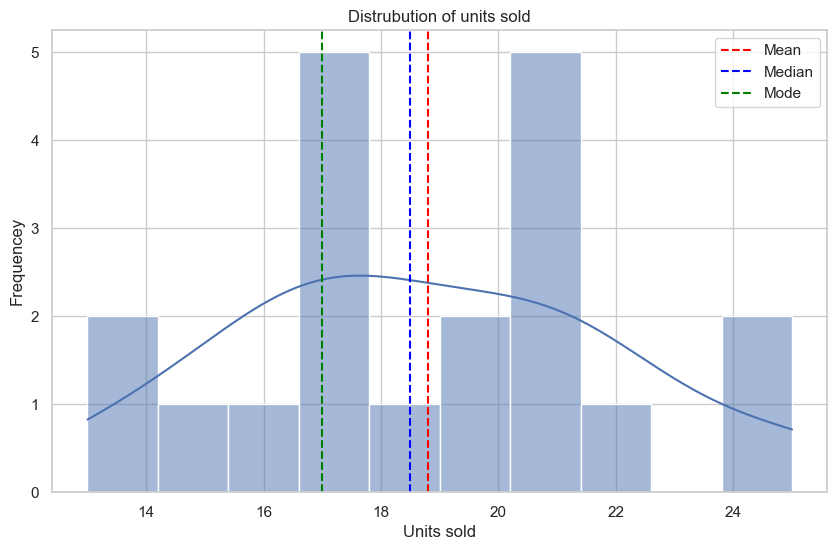

In [90]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(sales_data['units_sold'],bins=10,kde=True)
plt.title('Distrubution of units sold')
plt.xlabel('Units sold')
plt.ylabel('Frequencey')
plt.axvline(mean_sales,color='red',linestyle='--',label='Mean')
plt.axvline(median_sales,color='blue',linestyle='--',label='Median')
plt.axvline(mode_sales,color='green',linestyle='--',label='Mode')
plt.legend()
plt.show()


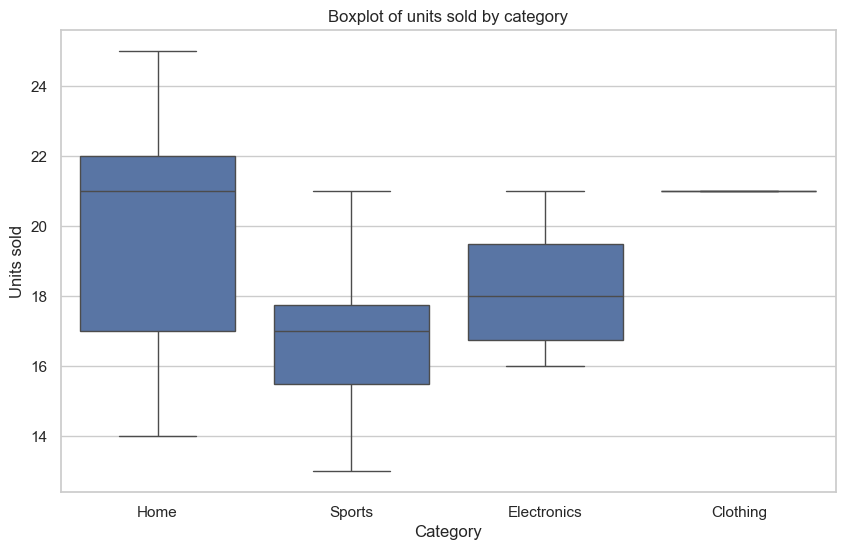

In [92]:
plt.figure(figsize=(10,6))
sns.boxplot(x='category',y='units_sold',data=sales_data)
plt.title('Boxplot of units sold by category')
plt.xlabel('Category')
plt.ylabel('Units sold')
plt.show()

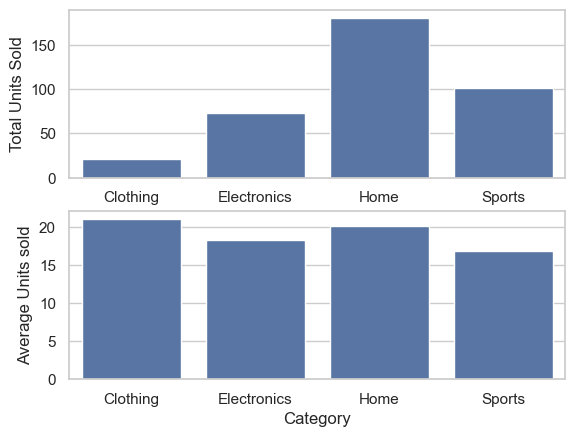

<Figure size 1000x1000 with 0 Axes>

In [126]:
fig,ax = plt.subplots(2)
plt.figure(figsize=(10,10))
sns.barplot(x='Category',y='Total Units Sold',data=category_stats,ax=ax[0])
sns.barplot(x='Category',y='Average Units sold',data=category_stats,ax=ax[1])
plt.show()